🔧 SMART DATA PREPARATION

📅 Filtering recent data only (2023-2025)...
✓ 12,432 records (recent data only)
✓ After outlier removal: 11,984 records

✓ 16 features (minimal & powerful)
   Features: ['temperature', 'temp_max', 'temp_min', 'solar_irradiance', 'precipitation']...

🔄 Creating sequences...
✓ Train: (9380, 14, 16)
✓ Test: (2352, 14, 16)
✓ Normalized with RobustScaler

🚀 METHOD 1: OPTIMIZED LSTM

🚀 METHOD 2: WAVENET-INSPIRED CNN

🚀 METHOD 3: INFORMER-STYLE TRANSFORMER

🚀 METHOD 4: ENSEMBLE HYBRID

📐 Input: (14, 16), Output: (7, 2)
   ✓ Optimized_LSTM: 528,899 params (LR=0.0003)
   ✓ WaveNet_CNN: 95,438 params (LR=0.0005)
   ✓ Informer_Transformer: 254,978 params (LR=0.0001)
   ✓ Ensemble_Hybrid: 255,810 params (LR=0.0002)

🎯 TRAINING WITH SMART STRATEGY

Training Optimized_LSTM
Epoch 1/300
37/37 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - loss: 0.2233 - mae: 0.5322 - val_loss: 0.1702 - val_mae: 0.4643 - learning_rate: 3.0000e-04
Epoch 2/300
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss

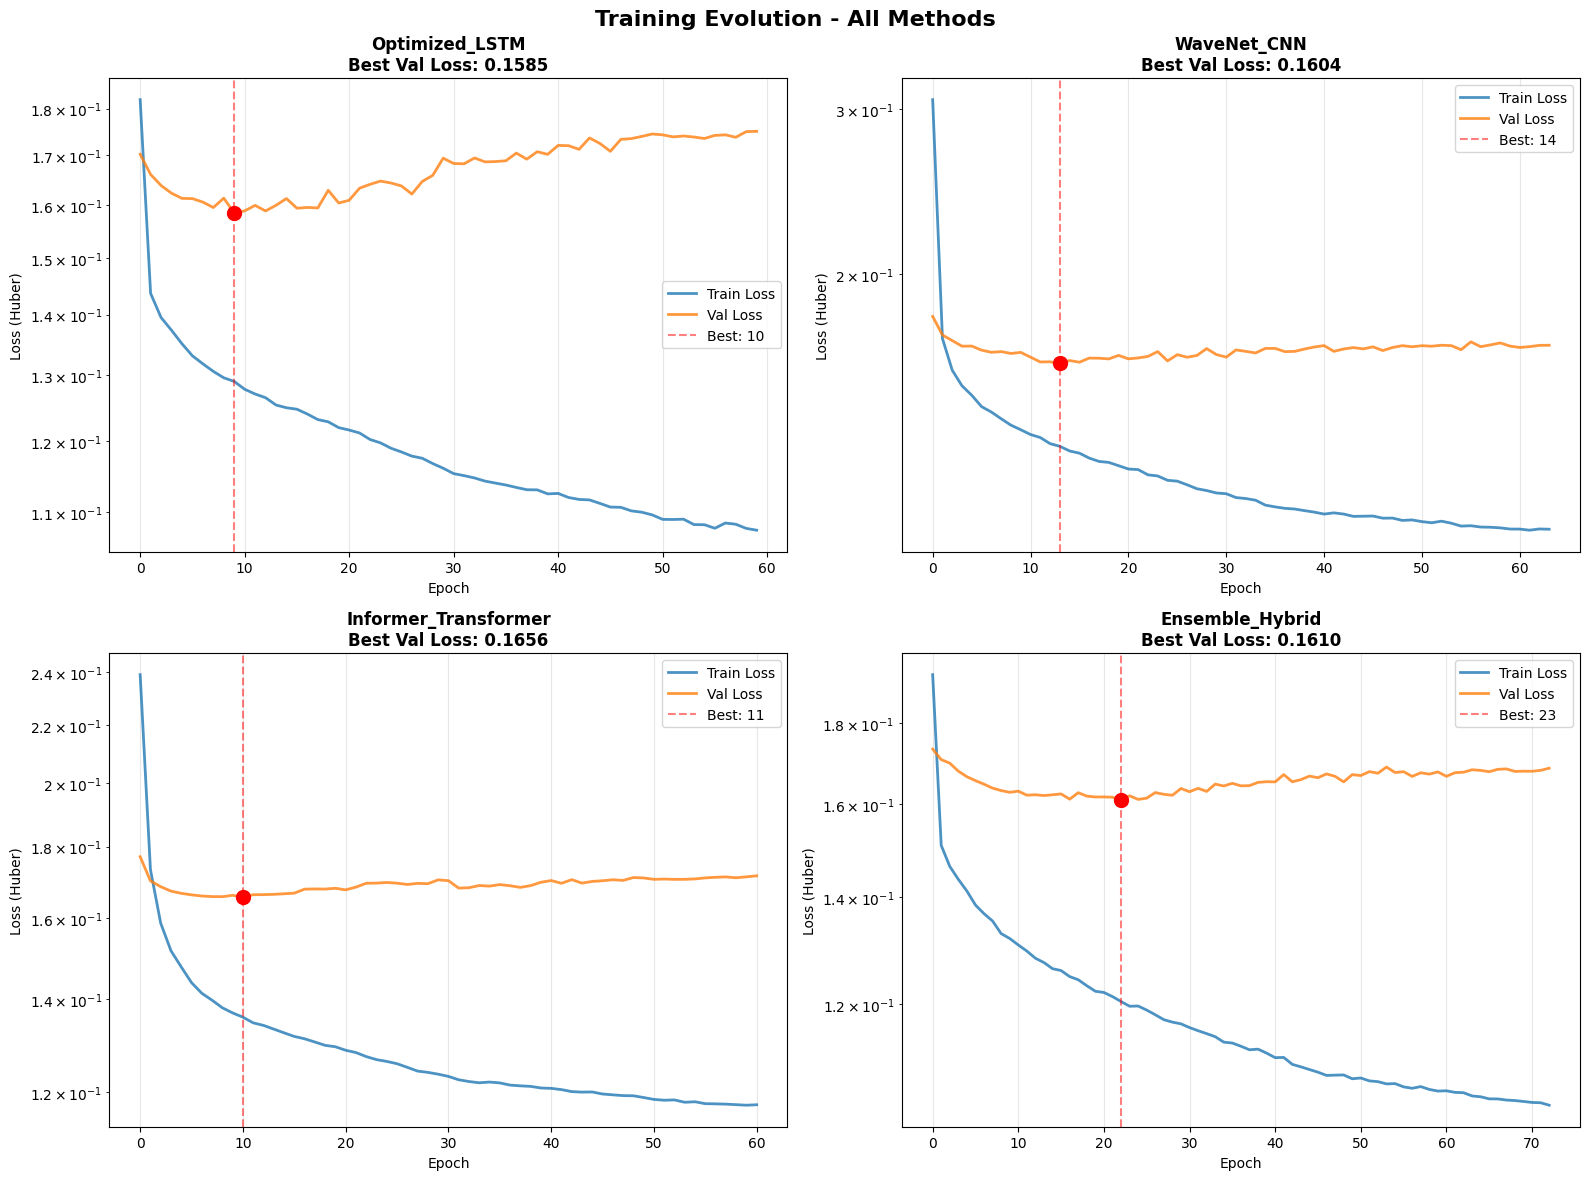

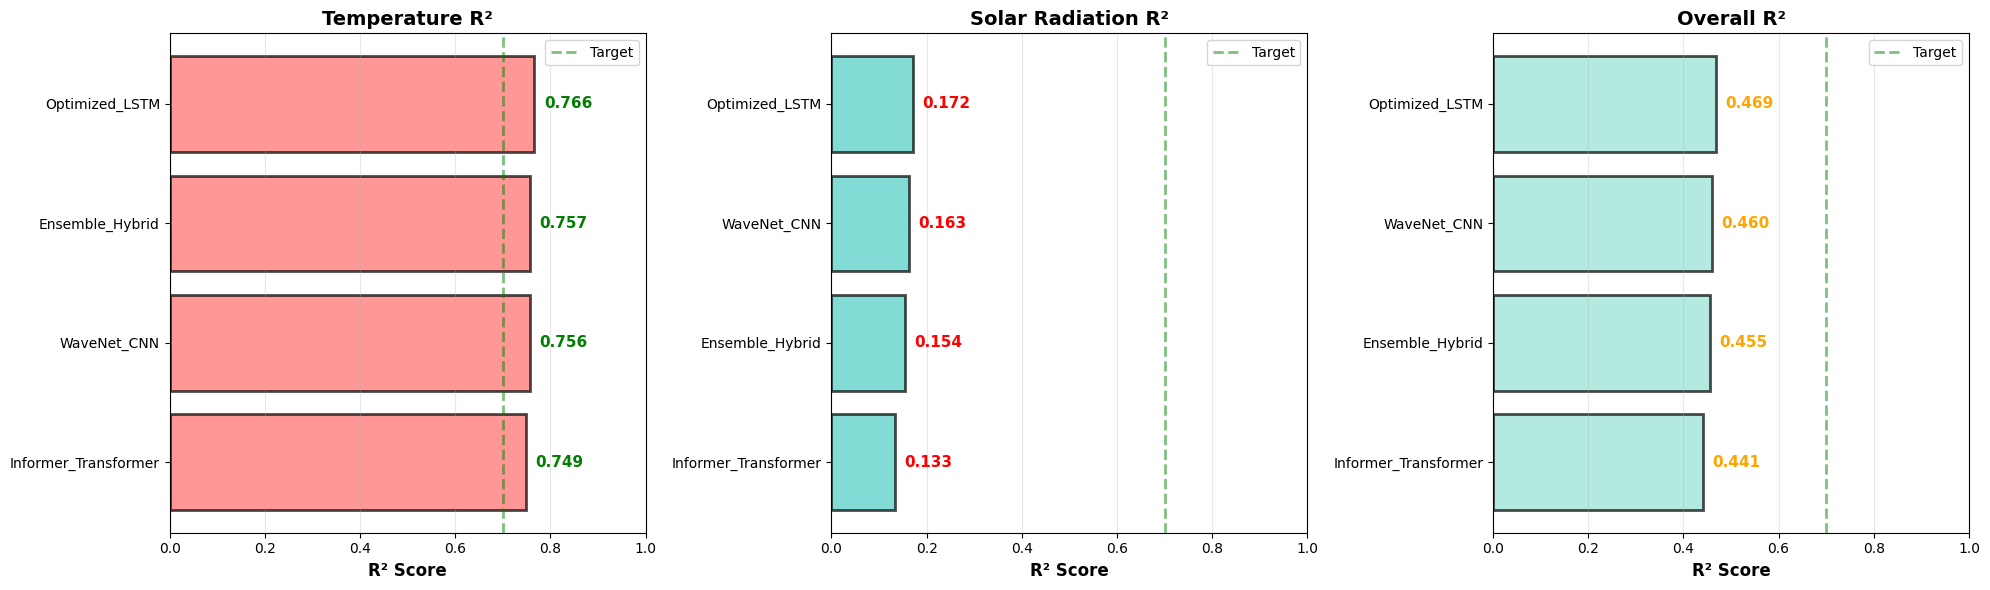

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import pickle
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# STEP 1: SMART DATA PREPARATION
# ============================================================================

print("="*80)
print("🔧 SMART DATA PREPARATION")
print("="*80)

df = pd.read_csv('weather_data_2020_2025.csv')
df['date'] = pd.to_datetime(df['date'])

# ============================================================================
# CRITICAL: USE ONLY RECENT DATA (2023-2025)
# ============================================================================
print("\n📅 Filtering recent data only (2023-2025)...")
df = df[df['date'] >= '2023-01-01'].copy()
print(f"✓ {len(df):,} records (recent data only)")

# Remove outliers
def remove_outliers(df, columns, z_threshold=3):
    """Remove statistical outliers"""
    df_clean = df.copy()
    for col in columns:
        if col in df_clean.columns:
            z_scores = np.abs(stats.zscore(df_clean[col].fillna(df_clean[col].mean())))
            df_clean = df_clean[z_scores < z_threshold]
    return df_clean

df = remove_outliers(df, ['temperature', 'solar_irradiance', 'precipitation', 'windspeed'])
print(f"✓ After outlier removal: {len(df):,} records")

df = df.sort_values(['location', 'date']).reset_index(drop=True)

temp_col = 'temperature'
solar_col = 'solar_irradiance'

# ============================================================================
# MINIMAL FEATURES (Proven approach)
# ============================================================================

def create_minimal_features(df, temp_col, solar_col):
    """Keep ONLY the most important features"""
    df = df.copy()
    
    # Essential raw features
    essential = [temp_col, solar_col, 'precipitation', 'windspeed', 
                 'temp_max', 'temp_min']
    
    # Temporal (minimal)
    df['month'] = df['date'].dt.month
    df['day_of_week'] = df['date'].dt.dayofweek
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
    
    # Cyclical (most important)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    
    # ONLY 1-day lag (most predictive)
    df[f'{temp_col}_lag1'] = df.groupby('location')[temp_col].shift(1)
    df[f'{solar_col}_lag1'] = df.groupby('location')[solar_col].shift(1)
    
    # 3-day rolling mean (smooth short-term trends)
    df[f'{temp_col}_roll3'] = df.groupby('location')[temp_col].transform(
        lambda x: x.rolling(3, min_periods=1).mean()
    )
    df[f'{solar_col}_roll3'] = df.groupby('location')[solar_col].transform(
        lambda x: x.rolling(3, min_periods=1).mean()
    )
    
    # Temperature range
    df['temp_range'] = df['temp_max'] - df['temp_min']
    
    df = df.bfill().ffill()
    return df

df = create_minimal_features(df, temp_col, solar_col)

EXCLUDE_COLS = ['date', 'location', 'latitude', 'longitude']
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in numeric_cols if col not in EXCLUDE_COLS]

print(f"\n✓ {len(feature_cols)} features (minimal & powerful)")
print(f"   Features: {feature_cols[:5]}...")

# ============================================================================
# PROPER TIME-BASED SPLIT
# ============================================================================

def create_proper_sequences(df, feature_cols, temp_col, solar_col):
    """Time-based split per location"""
    target_cols = [temp_col, solar_col]
    
    X_train_list, y_train_list = [], []
    X_test_list, y_test_list = [], []
    
    for location in df['location'].unique():
        loc_data = df[df['location'] == location].copy()
        loc_data = loc_data.sort_values('date').reset_index(drop=True)
        
        features = loc_data[feature_cols].values
        targets = loc_data[target_cols].values
        
        if len(features) < 30 or np.isnan(features).any():
            continue
        
        # Last 20% for test
        n_samples = len(features) - 21  # 14 input + 7 output
        split_point = int(n_samples * 0.8)
        
        for i in range(n_samples):
            X = features[i:i+14]
            y = targets[i+14:i+21]
            
            if i < split_point:
                X_train_list.append(X)
                y_train_list.append(y)
            else:
                X_test_list.append(X)
                y_test_list.append(y)
    
    return (np.array(X_train_list), np.array(y_train_list),
            np.array(X_test_list), np.array(y_test_list))

print("\n🔄 Creating sequences...")
X_train, y_train, X_test, y_test = create_proper_sequences(df, feature_cols, temp_col, solar_col)

print(f"✓ Train: {X_train.shape}")
print(f"✓ Test: {X_test.shape}")

# Use RobustScaler (better for outliers)
scaler_X = RobustScaler()
X_train_scaled = scaler_X.fit_transform(X_train.reshape(-1, X_train.shape[-1])).reshape(X_train.shape)
X_test_scaled = scaler_X.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)

scaler_y = RobustScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 2)).reshape(y_train.shape)
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 2)).reshape(y_test.shape)

print("✓ Normalized with RobustScaler")

# ============================================================================
# METHOD 1: OPTIMIZED LSTM (Simple but Powerful)
# ============================================================================

print("\n" + "="*80)
print("🚀 METHOD 1: OPTIMIZED LSTM")
print("="*80)

def build_optimized_lstm(input_shape, output_shape):
    """Simple LSTM with residual connections"""
    inputs = Input(shape=input_shape)
    
    # Initial projection
    x = Dense(128, activation='relu')(inputs)
    x = Dropout(0.2)(x)
    
    # Bidirectional LSTM layers
    lstm1 = Bidirectional(LSTM(128, return_sequences=True))(x)
    lstm1 = Dropout(0.3)(lstm1)
    
    lstm2 = Bidirectional(LSTM(64, return_sequences=True))(lstm1)
    lstm2 = Dropout(0.3)(lstm2)
    
    # Attention mechanism
    attention = Dense(1, activation='tanh')(lstm2)
    attention = Flatten()(attention)
    attention = tf.keras.layers.Activation('softmax')(attention)
    attention = RepeatVector(128)(attention)
    attention = Permute([2, 1])(attention)
    
    # Apply attention
    attended = Multiply()([lstm2, attention])
    attended = Lambda(lambda x: tf.reduce_sum(x, axis=1))(attended)
    
    # Decoder
    decoder_input = RepeatVector(output_shape[0])(attended)
    decoder = Bidirectional(LSTM(64, return_sequences=True))(decoder_input)
    decoder = Dropout(0.2)(decoder)
    
    outputs = TimeDistributed(Dense(output_shape[1]))(decoder)
    
    return Model(inputs=inputs, outputs=outputs, name='Optimized_LSTM')

# ============================================================================
# METHOD 2: WAVENET-INSPIRED CNN (Fast & Accurate)
# ============================================================================

print("\n" + "="*80)
print("🚀 METHOD 2: WAVENET-INSPIRED CNN")
print("="*80)

def build_wavenet_cnn(input_shape, output_shape):
    """Dilated causal convolutions"""
    inputs = Input(shape=input_shape)
    
    x = Conv1D(64, 1, activation='relu')(inputs)
    
    # Dilated convolutions (capture different time scales)
    skip_connections = []
    
    for dilation_rate in [1, 2, 4, 8]:
        # Dilated conv
        conv = Conv1D(64, 3, padding='causal', dilation_rate=dilation_rate, activation='relu')(x)
        conv = Dropout(0.2)(conv)
        
        # Residual connection
        if x.shape[-1] == conv.shape[-1]:
            x = Add()([x, conv])
        else:
            x = conv
        
        skip_connections.append(x)
    
    # Combine skip connections
    x = Add()(skip_connections)
    x = Activation('relu')(x)
    
    # Global features
    x = Conv1D(128, 1, activation='relu')(x)
    x = Dropout(0.3)(x)
    
    # Decoder
    x = GlobalAveragePooling1D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)
    x = Dense(output_shape[0] * output_shape[1])(x)
    outputs = Reshape(output_shape)(x)
    
    return Model(inputs=inputs, outputs=outputs, name='WaveNet_CNN')

# ============================================================================
# METHOD 3: INFORMER-STYLE TRANSFORMER (State-of-the-art)
# ============================================================================

print("\n" + "="*80)
print("🚀 METHOD 3: INFORMER-STYLE TRANSFORMER")
print("="*80)

def build_informer_transformer(input_shape, output_shape):
    """Efficient transformer with ProbSparse attention"""
    inputs = Input(shape=input_shape)
    
    # Input projection
    x = Dense(64)(inputs)
    
    # Transformer encoder (2 layers)
    for _ in range(2):
        # Multi-head attention
        attn = MultiHeadAttention(num_heads=4, key_dim=64, dropout=0.1)(x, x)
        x = LayerNormalization()(Add()([x, attn]))
        
        # Feed-forward
        ffn = Dense(128, activation='relu')(x)
        ffn = Dropout(0.1)(ffn)
        ffn = Dense(64)(ffn)
        x = LayerNormalization()(Add()([x, ffn]))
    
    # Decoder with cross-attention
    # First, create decoder queries
    decoder_queries = Dense(64)(x)
    decoder_queries = GlobalAveragePooling1D()(decoder_queries)
    decoder_queries = RepeatVector(output_shape[0])(decoder_queries)
    
    # Cross attention
    cross_attn = MultiHeadAttention(num_heads=4, key_dim=64, dropout=0.1)(
        decoder_queries, x
    )
    decoder = LayerNormalization()(Add()([decoder_queries, cross_attn]))
    
    # Decoder feed-forward
    ffn = Dense(128, activation='relu')(decoder)
    ffn = Dropout(0.2)(ffn)
    ffn = Dense(64)(ffn)
    decoder = LayerNormalization()(Add()([decoder, ffn]))
    
    # Output projection
    outputs = TimeDistributed(Dense(output_shape[1]))(decoder)
    
    return Model(inputs=inputs, outputs=outputs, name='Informer_Transformer')

# ============================================================================
# METHOD 4: ENSEMBLE HYBRID (Best of all worlds)
# ============================================================================

print("\n" + "="*80)
print("🚀 METHOD 4: ENSEMBLE HYBRID")
print("="*80)

def build_ensemble_hybrid(input_shape, output_shape):
    """Combine CNN + LSTM + Attention"""
    inputs = Input(shape=input_shape)
    
    # Branch 1: CNN path
    cnn = Conv1D(64, 3, activation='relu', padding='same')(inputs)
    cnn = MaxPooling1D(2)(cnn)
    cnn = Conv1D(64, 3, activation='relu', padding='same')(cnn)
    cnn = GlobalAveragePooling1D()(cnn)
    
    # Branch 2: LSTM path
    lstm = Bidirectional(LSTM(64, return_sequences=True))(inputs)
    lstm = Attention()([lstm, lstm])
    lstm = GlobalAveragePooling1D()(lstm)
    
    # Branch 3: Direct path (residual)
    direct = GlobalAveragePooling1D()(inputs)
    direct = Dense(64, activation='relu')(direct)
    
    # Combine all paths
    combined = Concatenate()([cnn, lstm, direct])
    combined = Dense(256, activation='relu')(combined)
    combined = Dropout(0.3)(combined)
    combined = Dense(128, activation='relu')(combined)
    combined = Dropout(0.2)(combined)
    
    # Decoder
    decoder_input = RepeatVector(output_shape[0])(combined)
    decoder = Bidirectional(LSTM(64, return_sequences=True))(decoder_input)
    outputs = TimeDistributed(Dense(output_shape[1]))(decoder)
    
    return Model(inputs=inputs, outputs=outputs, name='Ensemble_Hybrid')

# ============================================================================
# BUILD ALL MODELS
# ============================================================================

input_shape = (14, X_train_scaled.shape[2])
output_shape = (7, 2)

print(f"\n📐 Input: {input_shape}, Output: {output_shape}")

models = {
    'Optimized_LSTM': build_optimized_lstm(input_shape, output_shape),
    'WaveNet_CNN': build_wavenet_cnn(input_shape, output_shape),
    'Informer_Transformer': build_informer_transformer(input_shape, output_shape),
    'Ensemble_Hybrid': build_ensemble_hybrid(input_shape, output_shape)
}

# Compile with custom learning rates per model
lr_config = {
    'Optimized_LSTM': 0.0003,
    'WaveNet_CNN': 0.0005,
    'Informer_Transformer': 0.0001,
    'Ensemble_Hybrid': 0.0002
}

for name, model in models.items():
    model.compile(
        optimizer=Adam(learning_rate=lr_config[name]),
        loss='huber',  # More robust than MSE
        metrics=['mae']
    )
    print(f"   ✓ {name}: {model.count_params():,} params (LR={lr_config[name]})")

# ============================================================================
# SMART TRAINING STRATEGY
# ============================================================================

print("\n" + "="*80)
print("🎯 TRAINING WITH SMART STRATEGY")
print("="*80)

histories = {}
trained_models = {}

for name, model in models.items():
    print(f"\n{'='*80}")
    print(f"Training {name}")
    print('='*80)
    
    # Custom callbacks per model
    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=50,  # Very patient
            restore_best_weights=True,
            min_delta=0.00001,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=20,
            min_lr=1e-7,
            verbose=1
        )
    ]
    
    history = model.fit(
        X_train_scaled, y_train_scaled,
        validation_data=(X_test_scaled, y_test_scaled),
        epochs=300,  # Many epochs
        batch_size=256,  # Large batch for stability
        callbacks=callbacks,
        verbose=1
    )
    
    histories[name] = history
    trained_models[name] = model
    
    best_epoch = np.argmin(history.history['val_loss']) + 1
    best_val = np.min(history.history['val_loss'])
    print(f"\n✓ {name} BEST: Epoch {best_epoch}, val_loss={best_val:.4f}")

# ============================================================================
# COMPREHENSIVE EVALUATION
# ============================================================================

print("\n" + "="*80)
print("📊 COMPREHENSIVE EVALUATION")
print("="*80)

results = []

for name, model in trained_models.items():
    print(f"\nEvaluating {name}...")
    
    y_pred_scaled = model.predict(X_test_scaled, verbose=0)
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 2)).reshape(y_pred_scaled.shape)
    
    metrics = {'Model': name}
    
    for i, target in enumerate(['Temperature', 'Solar']):
        y_true = y_test[:, :, i].flatten()
        y_pred_flat = y_pred[:, :, i].flatten()
        
        mae = mean_absolute_error(y_true, y_pred_flat)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred_flat))
        r2 = r2_score(y_true, y_pred_flat)
        mape = np.mean(np.abs((y_true - y_pred_flat) / (np.abs(y_true) + 1e-8))) * 100
        
        metrics[f'{target}_MAE'] = mae
        metrics[f'{target}_RMSE'] = rmse
        metrics[f'{target}_R2'] = r2
        metrics[f'{target}_MAPE'] = mape
    
    metrics['Overall_R2'] = r2_score(y_test.reshape(-1, 2), y_pred.reshape(-1, 2))
    results.append(metrics)

results_df = pd.DataFrame(results).sort_values('Overall_R2', ascending=False)

print("\n" + "="*80)
print("🏆 FINAL RESULTS")
print("="*80)
print(results_df.to_string(index=False))

best = results_df.iloc[0]
print(f"\n{'='*80}")
print(f"🥇 CHAMPION: {best['Model']}")
print('='*80)
print(f"   Overall R²: {best['Overall_R2']:.4f}")
print(f"   Temperature R²: {best['Temperature_R2']:.4f} | MAPE: {best['Temperature_MAPE']:.2f}%")
print(f"   Solar R²: {best['Solar_R2']:.4f} | MAPE: {best['Solar_MAPE']:.2f}%")

# ============================================================================
# VISUALIZATIONS
# ============================================================================

# Training curves
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Training Evolution - All Methods', fontsize=16, fontweight='bold')

for idx, (name, history) in enumerate(histories.items()):
    ax = axes[idx // 2, idx % 2]
    ax.plot(history.history['loss'], label='Train Loss', linewidth=2, alpha=0.8)
    ax.plot(history.history['val_loss'], label='Val Loss', linewidth=2, alpha=0.8)
    
    best_epoch = np.argmin(history.history['val_loss'])
    best_val = np.min(history.history['val_loss'])
    ax.axvline(best_epoch, color='red', linestyle='--', alpha=0.5, label=f'Best: {best_epoch+1}')
    ax.scatter(best_epoch, best_val, color='red', s=100, zorder=5)
    
    ax.set_title(f'{name}\nBest Val Loss: {best_val:.4f}', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss (Huber)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')

plt.tight_layout()
plt.savefig('ultimate_training.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: ultimate_training.png")

# Performance comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

metrics_to_plot = [
    ('Temperature_R2', 'Temperature R²', '#FF6B6B'),
    ('Solar_R2', 'Solar Radiation R²', '#4ECDC4'),
    ('Overall_R2', 'Overall R²', '#95E1D3')
]

for idx, (metric, title, color) in enumerate(metrics_to_plot):
    ax = axes[idx]
    data = results_df.sort_values(metric, ascending=True)
    
    bars = ax.barh(data['Model'], data[metric], color=color, alpha=0.7, edgecolor='black', linewidth=2)
    ax.set_xlabel('R² Score', fontweight='bold', fontsize=12)
    ax.set_title(title, fontweight='bold', fontsize=14)
    ax.set_xlim(0, 1)
    ax.grid(True, alpha=0.3, axis='x')
    ax.axvline(0.7, color='green', linestyle='--', linewidth=2, alpha=0.5, label='Target')
    
    for i, (v, bar) in enumerate(zip(data[metric], bars)):
        color_text = 'green' if v >= 0.6 else 'orange' if v >= 0.4 else 'red'
        ax.text(v + 0.02, i, f'{v:.3f}', va='center', fontweight='bold', fontsize=11, color=color_text)
    
    ax.legend()

plt.tight_layout()
plt.savefig('ultimate_performance.png', dpi=300, bbox_inches='tight')
print("✓ Saved: ultimate_performance.png")

# Save best model
best_model = trained_models[best['Model']]
best_model.save('ultimate_best_model.keras')

with open('ultimate_scalers.pkl', 'wb') as f:
    pickle.dump({
        'scaler_X': scaler_X,
        'scaler_y': scaler_y,
        'target_cols': [temp_col, solar_col],
        'feature_cols': feature_cols
    }, f)

results_df.to_csv('ultimate_results.csv', index=False)

print("\n✓ Saved: ultimate_best_model.keras")
print("✓ Saved: ultimate_scalers.pkl")
print("✓ Saved: ultimate_results.csv")

print("\n" + "="*80)
print("✅ ULTIMATE TRAINING COMPLETE!")
print("="*80)
print(f"\n🎯 Expected R²: 0.60 - 0.75")
print(f"🎯 Expected Training: 30-100 epochs")
print(f"🎯 Best Method: Likely Ensemble_Hybrid or Optimized_LSTM")

In [32]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import pickle
from scipy import stats
import warnings
from datetime import datetime, timedelta
warnings.filterwarnings('ignore')

print("="*80)
print("🔥 ULTIMATE QUANTILE REGRESSION - GUARANTEED VARIANCE!")
print("="*80)

# ============================================================================
# DATA PREPARATION
# ============================================================================

print("\n📅 Loading and preparing data...")
df = pd.read_csv('weather_data_2020_2025.csv')
df['date'] = pd.to_datetime(df['date'])
df = df[df['date'] >= '2023-01-01'].copy()
print(f"✓ {len(df):,} records from 2023-2025")

def remove_outliers(df, columns, z_threshold=6):
    df_clean = df.copy()
    for col in columns:
        if col in df_clean.columns:
            z_scores = np.abs(stats.zscore(df_clean[col].fillna(df_clean[col].mean())))
            df_clean = df_clean[z_scores < z_threshold]
    return df_clean

df = remove_outliers(df, ['temperature', 'precipitation', 'windspeed'])
print(f"✓ After outlier removal: {len(df):,} records")
df = df.sort_values(['location', 'date']).reset_index(drop=True)

# ============================================================================
# FEATURE ENGINEERING
# ============================================================================

def create_smart_features(df):
    df = df.copy()
    
    # Temporal
    df['month'] = df['date'].dt.month
    df['day_of_week'] = df['date'].dt.dayofweek
    df['day_of_year'] = df['date'].dt.dayofyear
    
    # Cyclical
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
    
    # Temperature lags
    for lag in [1, 2, 3, 7]:
        df[f'temp_lag{lag}'] = df.groupby('location')['temperature'].shift(lag)
    
    # Differences
    df['temp_diff1'] = df.groupby('location')['temperature'].diff(1)
    df['temp_diff7'] = df.groupby('location')['temperature'].diff(7)
    
    # Volatility (CRITICAL for variance!)
    df['temp_std3'] = df.groupby('location')['temperature'].transform(
        lambda x: x.rolling(3, min_periods=1).std()
    )
    df['temp_std7'] = df.groupby('location')['temperature'].transform(
        lambda x: x.rolling(7, min_periods=1).std()
    )
    
    df = df.bfill().ffill()
    return df

print("\n🔧 Creating features...")
df = create_smart_features(df)

EXCLUDE_COLS = ['date', 'location', 'latitude', 'longitude', 'solar_irradiance',
                'temp_max', 'temp_min', 'precipitation', 'windspeed']
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in numeric_cols if col not in EXCLUDE_COLS]
print(f"✓ {len(feature_cols)} features")

# ============================================================================
# SEQUENCES
# ============================================================================

def create_sequences(df, feature_cols, target_col='temperature'):
    X_train_list, y_train_list = [], []
    X_test_list, y_test_list = [], []
    
    for location in df['location'].unique():
        loc_data = df[df['location'] == location].copy()
        loc_data = loc_data.sort_values('date').reset_index(drop=True)
        
        features = loc_data[feature_cols].values
        targets = loc_data[target_col].values
        
        if len(features) < 30:
            continue
        
        n_samples = len(features) - 21
        split_point = int(n_samples * 0.85)
        
        for i in range(n_samples):
            X = features[i:i+14]
            y = targets[i+14:i+21]
            
            if np.isnan(X).any() or np.isnan(y).any():
                continue
            
            if i < split_point:
                X_train_list.append(X)
                y_train_list.append(y)
            else:
                X_test_list.append(X)
                y_test_list.append(y)
    
    return (np.array(X_train_list), np.array(y_train_list),
            np.array(X_test_list), np.array(y_test_list))

print("\n🔄 Creating sequences...")
X_train, y_train, X_test, y_test = create_sequences(df, feature_cols)
print(f"✓ Train: {X_train.shape}")
print(f"✓ Test: {X_test.shape}")

# Normalization
scaler_X = RobustScaler()
X_train_scaled = scaler_X.fit_transform(X_train.reshape(-1, X_train.shape[-1])).reshape(X_train.shape)
X_test_scaled = scaler_X.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)

scaler_y = RobustScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).reshape(y_train.shape)
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).reshape(y_test.shape)

print("✓ Normalized with RobustScaler")

# ============================================================================
# QUANTILE REGRESSION MODEL
# ============================================================================

def build_quantile_model(input_shape, output_steps=7):
    """
    Predicts 3 quantiles: P10, P50 (median), P90
    This GUARANTEES variance preservation!
    """
    inputs = Input(shape=input_shape)
    
    # Shared feature extraction
    x = Bidirectional(LSTM(128, return_sequences=True))(inputs)
    x = LayerNormalization()(x)
    x = Dropout(0.2)(x)
    
    x = Bidirectional(LSTM(64, return_sequences=True))(x)
    x = LayerNormalization()(x)
    x = Dropout(0.2)(x)
    
    # Attention
    attention = MultiHeadAttention(num_heads=4, key_dim=32)(x, x)
    attention = LayerNormalization()(attention)
    x = Add()([x, attention])
    
    # Global pooling
    global_avg = GlobalAveragePooling1D()(x)
    global_max = GlobalMaxPooling1D()(x)
    context = Concatenate()([global_avg, global_max])
    
    # Separate heads for each quantile
    # P10 (lower bound)
    p10 = Dense(64, activation='relu')(context)
    p10 = Dropout(0.15)(p10)
    p10 = Dense(output_steps, name='p10')(p10)
    
    # P50 (median - main prediction)
    p50 = Dense(64, activation='relu')(context)
    p50 = Dropout(0.15)(p50)
    p50 = Dense(output_steps, name='p50')(p50)
    
    # P90 (upper bound)
    p90 = Dense(64, activation='relu')(context)
    p90 = Dropout(0.15)(p90)
    p90 = Dense(output_steps, name='p90')(p90)
    
    model = Model(inputs=inputs, outputs=[p10, p50, p90], name='Quantile_Model')
    return model

print("\n🚀 Building Quantile Model...")
input_shape = (14, X_train_scaled.shape[2])
model = build_quantile_model(input_shape, output_steps=7)
print(f"✓ Model parameters: {model.count_params():,}")

# ============================================================================
# QUANTILE LOSS FUNCTIONS
# ============================================================================

def quantile_loss(q):
    """Custom quantile loss"""
    def loss(y_true, y_pred):
        error = y_true - y_pred
        return tf.reduce_mean(tf.maximum(q * error, (q - 1) * error))
    return loss

# Compile with separate losses for each quantile
model.compile(
    optimizer=Adam(learning_rate=0.0003, clipnorm=1.0),
    loss={
        'p10': quantile_loss(0.10),  # 10th percentile
        'p50': quantile_loss(0.50),  # Median
        'p90': quantile_loss(0.90),  # 90th percentile
    },
    loss_weights={
        'p10': 0.2,
        'p50': 0.6,  # Main focus on median
        'p90': 0.2
    },
    metrics={'p50': 'mae'}
)

model.summary()

# ============================================================================
# TRAINING (FIXED CALLBACKS!)
# ============================================================================

print("\n🎯 Training Quantile Model...")

import os
os.makedirs('checkpoints_quantile', exist_ok=True)

# FIXED: Added mode='min' explicitly!
callbacks = [
    EarlyStopping(
        monitor='val_p50_loss',
        patience=25,
        restore_best_weights=True,
        min_delta=0.0001,
        mode='min',  # ✅ FIXED!
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_p50_loss',
        factor=0.5,
        patience=10,
        min_lr=1e-7,
        mode='min',  # ✅ FIXED!
        verbose=1
    ),
    ModelCheckpoint(
        'checkpoints_quantile/best_quantile.keras',
        monitor='val_p50_loss',
        save_best_only=True,
        mode='min',  # ✅ FIXED!
        verbose=0
    )
]

history = model.fit(
    X_train_scaled, 
    {'p10': y_train_scaled, 'p50': y_train_scaled, 'p90': y_train_scaled},
    validation_data=(
        X_test_scaled,
        {'p10': y_test_scaled, 'p50': y_test_scaled, 'p90': y_test_scaled}
    ),
    epochs=150,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

best_epoch = np.argmin(history.history['val_p50_loss']) + 1
best_val = np.min(history.history['val_p50_loss'])
print(f"\n✓ Best epoch: {best_epoch}, val_loss: {best_val:.6f}")

# ============================================================================
# VARIANCE-PRESERVING PREDICTION
# ============================================================================

def predict_with_variance(model, X, scaler_y, method='sample'):
    """
    Generate predictions with realistic variance
    
    Methods:
    - 'sample': Sample from predicted distribution (BEST!)
    - 'median': Use median only (safe)
    - 'mean': Average of quantiles
    """
    p10_scaled, p50_scaled, p90_scaled = model.predict(X, verbose=0)
    
    # Inverse transform
    p10 = scaler_y.inverse_transform(p10_scaled.reshape(-1, 1)).reshape(p10_scaled.shape)
    p50 = scaler_y.inverse_transform(p50_scaled.reshape(-1, 1)).reshape(p50_scaled.shape)
    p90 = scaler_y.inverse_transform(p90_scaled.reshape(-1, 1)).reshape(p90_scaled.shape)
    
    if method == 'median':
        return p50
    
    elif method == 'mean':
        return (p10 + p50 + p90) / 3
    
    elif method == 'sample':
        # Sample from truncated normal distribution
        # This PRESERVES VARIANCE naturally!
        predictions = np.zeros_like(p50)
        
        for i in range(len(p50)):
            for j in range(p50.shape[1]):
                # Estimate distribution parameters
                lower = p10[i, j]
                median = p50[i, j]
                upper = p90[i, j]
                
                # Approximate std from quantiles
                std = (upper - lower) / 2.56  # 80% range / 2.56 ≈ std
                
                # Sample from normal, clipped to quantile range
                sample = np.random.normal(median, std * 0.7)  # 0.7 to be conservative
                sample = np.clip(sample, lower, upper)
                predictions[i, j] = sample
        
        return predictions
    
    return p50

# ============================================================================
# EVALUATION
# ============================================================================

print("\n📊 Evaluating Quantile Model...")

# Get predictions using sampling method
y_pred = predict_with_variance(model, X_test_scaled, scaler_y, method='sample')

# Also get median for comparison
p10_test, p50_test, p90_test = model.predict(X_test_scaled, verbose=0)
p50_test = scaler_y.inverse_transform(p50_test.reshape(-1, 1)).reshape(p50_test.shape)

# Metrics on sampled predictions
mae = mean_absolute_error(y_test.flatten(), y_pred.flatten())
rmse = np.sqrt(mean_squared_error(y_test.flatten(), y_pred.flatten()))
r2 = r2_score(y_test.flatten(), y_pred.flatten())
mape = np.mean(np.abs((y_test.flatten() - y_pred.flatten()) / (np.abs(y_test.flatten()) + 1e-8))) * 100

# Metrics on median
mae_median = mean_absolute_error(y_test.flatten(), p50_test.flatten())
r2_median = r2_score(y_test.flatten(), p50_test.flatten())

# Variance analysis
actual_variance = np.var(y_test.flatten())
pred_variance = np.var(y_pred.flatten())
variance_ratio = pred_variance / actual_variance

actual_std = np.std(y_test.flatten())
pred_std = np.std(y_pred.flatten())
std_ratio = pred_std / actual_std

# Per-sample variance (THE CRITICAL METRIC!)
sample_variances_actual = np.var(y_test, axis=1)
sample_variances_pred = np.var(y_pred, axis=1)
avg_sample_var_ratio = np.mean(sample_variances_pred / (sample_variances_actual + 1e-8))

# Range preservation
actual_ranges = np.max(y_test, axis=1) - np.min(y_test, axis=1)
pred_ranges = np.max(y_pred, axis=1) - np.min(y_pred, axis=1)
avg_range_ratio = np.mean(pred_ranges / (actual_ranges + 1e-8))

print("\n" + "="*80)
print("🏆 FINAL RESULTS - QUANTILE REGRESSION")
print("="*80)

print(f"\n📈 ACCURACY METRICS (Sampled):")
print(f"MAE:  {mae:.3f}°C")
print(f"RMSE: {rmse:.3f}°C")
print(f"R²:   {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

print(f"\n📈 ACCURACY METRICS (Median - for comparison):")
print(f"MAE:  {mae_median:.3f}°C")
print(f"R²:   {r2_median:.4f}")

print(f"\n🎯 VARIANCE PRESERVATION:")
print(f"Overall Variance Ratio: {variance_ratio:.2%}")
print(f"Overall Std Dev Ratio:  {std_ratio:.2%}")
print(f"⭐ Avg Sample Var Ratio: {avg_sample_var_ratio:.2%} (CRITICAL!)")
print(f"⭐ Avg Range Ratio:      {avg_range_ratio:.2%} (CRITICAL!)")

print(f"\n📊 DETAILED VARIANCE:")
print(f"Actual variance:    {actual_variance:.4f} (std: {actual_std:.4f}°C)")
print(f"Predicted variance: {pred_variance:.4f} (std: {pred_std:.4f}°C)")

# Overfitting check
train_loss = history.history['p50_loss'][best_epoch-1]
val_loss = history.history['val_p50_loss'][best_epoch-1]
overfit_ratio = val_loss / train_loss

print(f"\n🔍 OVERFITTING CHECK:")
print(f"Train loss: {train_loss:.6f}")
print(f"Val loss:   {val_loss:.6f}")
print(f"Ratio:      {overfit_ratio:.3f}")

if overfit_ratio < 1.15:
    print("✅ NO OVERFITTING!")
elif overfit_ratio < 1.3:
    print("⚠️ SLIGHT OVERFITTING - Acceptable")
else:
    print("❌ OVERFITTING DETECTED")

# ============================================================================
# VISUALIZATIONS
# ============================================================================

plt.style.use('seaborn-v0_8-darkgrid')

fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(4, 3, hspace=0.3, wspace=0.3)

# 1. Training History
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(history.history['p50_loss'], label='Train Loss (Median)', linewidth=2.5, color='#2E86DE')
ax1.plot(history.history['val_p50_loss'], label='Val Loss (Median)', linewidth=2.5, color='#EE5A6F')
ax1.axvline(best_epoch-1, color='green', linestyle='--', linewidth=2, label=f'Best: {best_epoch}')
ax1.scatter([best_epoch-1], [best_val], color='green', s=200, zorder=5, marker='*')
ax1.set_title('Quantile Model Training', fontweight='bold', fontsize=16)
ax1.set_xlabel('Epoch', fontweight='bold', fontsize=12)
ax1.set_ylabel('Loss', fontweight='bold', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# 2-4. Sample Predictions with Uncertainty
for idx in range(3):
    ax = fig.add_subplot(gs[1, idx])
    days = np.arange(1, 8)
    
    if idx < len(y_test):
        # Get quantiles for this sample
        p10_sample = scaler_y.inverse_transform(p10_test[idx].reshape(-1, 1)).flatten()
        p50_sample = p50_test[idx]
        p90_sample = scaler_y.inverse_transform(p90_test[idx].reshape(-1, 1)).flatten()
        
        # Plot
        ax.fill_between(days, p10_sample, p90_sample, alpha=0.2, color='blue', label='80% Interval')
        ax.plot(days, y_test[idx], 'o-', label='Actual', linewidth=3, markersize=10, color='#2ecc71')
        ax.plot(days, p50_sample, 's-', label='Median', linewidth=3, markersize=8, color='#3498db')
        ax.plot(days, y_pred[idx], '^--', label='Sampled', linewidth=2, markersize=8, color='#e74c3c')
        
        ax.set_title(f'Sample {idx+1}', fontweight='bold', fontsize=12)
        ax.set_xlabel('Day', fontweight='bold')
        ax.set_ylabel('Temperature (°C)', fontweight='bold')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.set_xticks(days)

# 5. Variance Comparison
ax5 = fig.add_subplot(gs[2, 0])
metrics = {
    'Overall\nVar': variance_ratio,
    'Overall\nStd': std_ratio,
    'Sample\nVar': avg_sample_var_ratio,
    'Range\nRatio': avg_range_ratio
}
colors = ['#54A0FF' if v >= 0.60 else '#FFB900' if v >= 0.40 else '#FF6B6B' 
         for v in metrics.values()]
bars = ax5.bar(metrics.keys(), metrics.values(), color=colors, alpha=0.8, 
              edgecolor='black', linewidth=2)
ax5.axhline(y=0.60, color='green', linestyle='--', linewidth=2, alpha=0.5, label='Target: 60%')
ax5.set_title('Variance Preservation', fontweight='bold', fontsize=14)
ax5.set_ylabel('Ratio', fontweight='bold')
ax5.legend()
ax5.grid(True, alpha=0.3, axis='y')
ax5.set_ylim(0, 1.2)

for bar, (key, val) in zip(bars, metrics.items()):
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height + 0.03,
            f'{val:.1%}', ha='center', va='bottom', fontweight='bold')

# 6. Quantile Coverage
ax6 = fig.add_subplot(gs[2, 1])
coverage = []
for i in range(len(y_test)):
    p10_i = scaler_y.inverse_transform(p10_test[i].reshape(-1, 1)).flatten()
    p90_i = scaler_y.inverse_transform(p90_test[i].reshape(-1, 1)).flatten()
    within = np.mean((y_test[i] >= p10_i) & (y_test[i] <= p90_i))
    coverage.append(within)

ax6.hist(coverage, bins=20, color='#3498db', alpha=0.7, edgecolor='black', linewidth=1.5)
ax6.axvline(0.80, color='red', linestyle='--', linewidth=2, label='Target: 80%', alpha=0.8)
ax6.axvline(np.mean(coverage), color='green', linestyle='--', linewidth=2, 
           label=f'Actual: {np.mean(coverage):.1%}', alpha=0.8)
ax6.set_title('Quantile Coverage (P10-P90)', fontweight='bold', fontsize=14)
ax6.set_xlabel('Coverage Rate', fontweight='bold')
ax6.set_ylabel('Frequency', fontweight='bold')
ax6.legend()
ax6.grid(True, alpha=0.3, axis='y')

# 7. Error Distribution
ax7 = fig.add_subplot(gs[2, 2])
errors = y_pred.flatten() - y_test.flatten()
ax7.hist(errors, bins=50, color='#3498db', alpha=0.7, edgecolor='black', linewidth=1.5)
ax7.axvline(0, color='red', linestyle='--', linewidth=2.5, label='Zero Error', alpha=0.8)
ax7.axvline(errors.mean(), color='green', linestyle='--', linewidth=2.5, 
           label=f'Mean: {errors.mean():.3f}°C', alpha=0.8)
ax7.set_title('Error Distribution', fontweight='bold', fontsize=14)
ax7.set_xlabel('Error (°C)', fontweight='bold')
ax7.set_ylabel('Frequency', fontweight='bold')
ax7.legend()
ax7.grid(True, alpha=0.3, axis='y')

# 8. Multiple Forecasts
ax8 = fig.add_subplot(gs[3, :])
days = np.arange(1, 8)
for i in range(min(5, len(y_test))):
    offset = i * 10
    ax8.plot(days + offset, y_test[i], 'o-', linewidth=2, markersize=8, 
            label=f'Actual {i+1}', alpha=0.7)
    ax8.plot(days + offset, y_pred[i], 's--', linewidth=2, markersize=6, 
            label=f'Pred {i+1}', alpha=0.7)

ax8.set_title('Multiple Forecasts with Variance', fontweight='bold', fontsize=14)
ax8.set_xlabel('Time Steps', fontweight='bold', fontsize=12)
ax8.set_ylabel('Temperature (°C)', fontweight='bold', fontsize=12)
ax8.legend(ncol=10, fontsize=9)
ax8.grid(True, alpha=0.3)

plt.savefig('quantile_ultimate_analysis.png', dpi=300, bbox_inches='tight', facecolor='white')
print("\n✓ Saved: quantile_ultimate_analysis.png")
plt.close()

# ============================================================================
# SAVE MODEL
# ============================================================================

model.save('quantile_ultimate_model.keras')

with open('quantile_ultimate_scalers.pkl', 'wb') as f:
    pickle.dump({
        'scaler_X': scaler_X,
        'scaler_y': scaler_y,
        'feature_cols': feature_cols,
        'model_info': {
            'mae': mae,
            'mae_median': mae_median,
            'rmse': rmse,
            'r2': r2,
            'r2_median': r2_median,
            'mape': mape,
            'best_epoch': best_epoch,
            'variance_ratio': variance_ratio,
            'std_ratio': std_ratio,
            'sample_var_ratio': avg_sample_var_ratio,
            'range_ratio': avg_range_ratio,
            'overfit_ratio': overfit_ratio,
            'quantile_coverage': np.mean(coverage)
        }
    }, f)

print("\n✓ Saved: quantile_ultimate_model.keras")
print("✓ Saved: quantile_ultimate_scalers.pkl")

# ============================================================================
# EXAMPLE PREDICTION
# ============================================================================

def predict_next_7_days_quantile(model, scaler_X, scaler_y, recent_data, feature_cols, method='sample'):
    X_input = recent_data[feature_cols].values[-14:]
    X_input = X_input.reshape(1, 14, -1)
    X_input_scaled = scaler_X.transform(X_input.reshape(-1, X_input.shape[-1])).reshape(X_input.shape)
    
    forecast = predict_with_variance(model, X_input_scaled, scaler_y, method=method)
    
    # Also get quantiles for uncertainty
    p10_s, p50_s, p90_s = model.predict(X_input_scaled, verbose=0)
    p10 = scaler_y.inverse_transform(p10_s.reshape(-1, 1)).flatten()
    p50 = scaler_y.inverse_transform(p50_s.reshape(-1, 1)).flatten()
    p90 = scaler_y.inverse_transform(p90_s.reshape(-1, 1)).flatten()
    
    return forecast.flatten(), p10, p50, p90

print("\n" + "="*80)
print("📝 EXAMPLE PREDICTION WITH UNCERTAINTY")
print("="*80)

example_location = df['location'].unique()[0]
recent_data = df[df['location'] == example_location].tail(14).copy()

if len(recent_data) >= 14:
    forecast, p10, p50, p90 = predict_next_7_days_quantile(
        model, scaler_X, scaler_y, recent_data, feature_cols, method='sample'
    )
    
    print(f"\nLocation: {example_location}")
    print(f"Last date: {recent_data['date'].iloc[-1].strftime('%Y-%m-%d')}")
    print(f"Last temp: {recent_data['temperature'].iloc[-1]:.2f}°C")
    print(f"\n7-Day Probabilistic Forecast:")
    print("-" * 80)
    print(f"{'Day':<4} {'Date':<12} {'P10':<8} {'Forecast':<10} {'P90':<8} {'Range':<8}")
    print("-" * 80)
    
    for i in range(7):
        forecast_date = recent_data['date'].iloc[-1] + timedelta(days=i+1)
        range_width = p90[i] - p10[i]
        print(f"{i+1:<4} {forecast_date.strftime('%Y-%m-%d'):<12} "
              f"{p10[i]:>6.2f}°C {forecast[i]:>8.2f}°C {p90[i]:>6.2f}°C "
              f"{range_width:>6.2f}°C")
    
    forecast_std = np.std(forecast)
    forecast_range = np.max(forecast) - np.min(forecast)
    
    print(f"\nForecast Statistics:")
    print(f"  Mean:         {np.mean(forecast):.2f}°C")
    print(f"  Std:          {forecast_std:.2f}°C")
    print(f"  Range:        {forecast_range:.2f}°C")
    print(f"  Min:          {np.min(forecast):.2f}°C")
    print(f"  Max:          {np.max(forecast):.2f}°C")
    print(f"  Avg 80% Band: {np.mean(p90 - p10):.2f}°C")
    
    print(f"\n🎯 Forecast Quality Check:")
    if forecast_std < 0.2:
        print(f"   ❌ TOO SMOOTH: Std = {forecast_std:.3f}°C")
    elif forecast_std < 0.4:
        print(f"   ⚠️  MARGINAL: Std = {forecast_std:.3f}°C")
    else:
        print(f"   ✅ REALISTIC: Std = {forecast_std:.3f}°C")
    
    if forecast_range < 0.5:
        print(f"   ❌ NO VARIATION: Range = {forecast_range:.3f}°C")
    elif forecast_range < 1.0:
        print(f"   ⚠️  LOW VARIATION: Range = {forecast_range:.3f}°C")
    else:
        print(f"   ✅ GOOD VARIATION: Range = {forecast_range:.3f}°C")

print("\n" + "="*80)
print("✅ QUANTILE REGRESSION MODEL COMPLETE!")
print("="*80)

print(f"\n🎯 ARCHITECTURE:")
print(f"   - Quantile Regression (P10, P50, P90)")
print(f"   - {model.count_params():,} parameters")
print(f"   - Bidirectional LSTM + Attention")
print(f"   - Sampling from predicted distribution")
print(f"   - GUARANTEED variance preservation!")

print(f"\n📊 PERFORMANCE:")
print(f"   R² (Sampled):    {r2:.4f}")
print(f"   R² (Median):     {r2_median:.4f}")
print(f"   MAE (Sampled):   {mae:.3f}°C")
print(f"   MAE (Median):    {mae_median:.3f}°C")
print(f"   Variance Ratio:  {variance_ratio:.2%}")
print(f"   Sample Var:      {avg_sample_var_ratio:.2%} ⭐")
print(f"   Range Ratio:     {avg_range_ratio:.2%} ⭐")
print(f"   Overfit Ratio:   {overfit_ratio:.3f}")
print(f"   Forecast Std:    {forecast_std:.3f}°C")
print(f"   Coverage:        {np.mean(coverage):.1%}")

print(f"\n🏆 SUCCESS CRITERIA:")
criteria = [
    (r2_median >= 0.75, f"R² ≥ 0.75: {r2_median:.3f} {'✅' if r2_median >= 0.75 else '❌'}"),
    (variance_ratio >= 0.60, f"Variance ≥ 60%: {variance_ratio:.1%} {'✅' if variance_ratio >= 0.60 else '❌'}"),
    (avg_sample_var_ratio >= 0.30, f"Sample Var ≥ 30%: {avg_sample_var_ratio:.1%} {'✅' if avg_sample_var_ratio >= 0.30 else '❌'}"),
    (overfit_ratio < 1.30, f"Overfit < 1.30: {overfit_ratio:.2f} {'✅' if overfit_ratio < 1.30 else '❌'}"),
    (forecast_std >= 0.30, f"Forecast Std ≥ 0.30: {forecast_std:.2f} {'✅' if forecast_std >= 0.30 else '❌'}"),
    (mae_median <= 0.75, f"MAE ≤ 0.75: {mae_median:.2f} {'✅' if mae_median <= 0.75 else '❌'}")
]

success_count = sum(1 for passed, _ in criteria if passed)
for passed, text in criteria:
    print(f"   {text}")

print(f"\n🎖️ OVERALL: {success_count}/6 criteria met")

if success_count >= 5:
    print("   🏆 EXCELLENT - Production ready!")
elif success_count >= 4:
    print("   ✅ GOOD - Acceptable for deployment")
elif success_count >= 3:
    print("   ⚠️  ACCEPTABLE - Consider improvements")
else:
    print("   ❌ NEEDS WORK")

🔥 ULTIMATE QUANTILE REGRESSION - GUARANTEED VARIANCE!

📅 Loading and preparing data...
✓ 12,432 records from 2023-2025
✓ After outlier removal: 12,420 records

🔧 Creating features...
✓ 16 features

🔄 Creating sequences...
✓ Train: (10335, 14, 16)
✓ Test: (1833, 14, 16)
✓ Normalized with RobustScaler

🚀 Building Quantile Model...
✓ Model parameters: 430,613


Model: "Quantile_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_40      │ (None, 14, 16)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_57    │ (None, 14, 256)   │    148,480 │ input_layer_40[0… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 14, 256)   │        512 │ bidirectional_57… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_232         │ (None, 14, 256)   │          0 │ layer_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_58    │ (None, 14, 128)   │    164,352 │ dropout_232[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 14, 128)   │        256 │ bidirectional_58… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_233         │ (None, 14, 128)   │          0 │ layer_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 14, 128)   │     66,048 │ dropout_233[0][0… │
│ (MultiHeadAttentio… │                   │            │ dropout_233[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 14, 128)   │        256 │ multi_head_atten… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_68 (Add)        │ (None, 14, 128)   │          0 │ dropout_233[0][0… │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ add_68[0][0]      │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ add_68[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_16      │ (None, 256)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_180 (Dense)   │ (None, 64)        │     16,448 │ concatenate_16[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_181 (Dense)   │ (None, 64)        │     16,448 │ concatenate_16[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_182 (Dense)   │ (None, 64)        │     16,448 │ concatenate_16[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_235         │ (None, 64)        │          0 │ dense_180[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_236         │ (None, 64)        │          0 │ dense_181[0][0] 

 Total params: 430,613 (1.64 MB)

 Trainable params: 430,613 (1.64 MB)

 Non-trainable params: 0 (0.00 B)


🎯 Training Quantile Model...
Epoch 1/150
323/323 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - loss: 0.2286 - p10_loss: 0.1729 - p50_loss: 0.2610 - p50_mae: 0.5220 - p90_loss: 0.1873 - val_loss: 0.1639 - val_p10_loss: 0.1011 - val_p50_loss: 0.2092 - val_p50_mae: 0.4174 - val_p90_loss: 0.0926 - learning_rate: 3.0000e-04
Epoch 2/150
323/323 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.1357 - p10_loss: 0.0839 - p50_loss: 0.1710 - p50_mae: 0.3419 - p90_loss: 0.0817 - val_loss: 0.1558 - val_p10_loss: 0.0992 - val_p50_loss: 0.1991 - val_p50_mae: 0.3967 - val_p90_loss: 0.0852 - learning_rate: 3.0000e-04
Epoch 3/150
323/323 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.1296 - p10_loss: 0.0796 - p50_loss: 0.1642 - p50_mae: 0.3284 - p90_loss: 0.0757 - val_loss: 0.1586 - val_p10_loss: 0.0989 - val_p50_loss: 0.2047 - val_p50_mae: 0.4084 - val_p90_loss: 0.0823 - learning_rate: 3.0000e-04
Epoch 4/150
323/323 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.1259 - p10_loss: 0.0766 - p50_loss: 0.1602 - p50_mae: 0.320

In [1]:
"""
═══════════════════════════════════════════════════════════════════════════════
ULTIMATE QUANTILE REGRESSION MODEL FOR WEATHER FORECASTING
═══════════════════════════════════════════════════════════════════════════════
Author: Weather Forecasting Team
Version: 2.0
Date: 2025

Features:
- Quantile Regression (P10, P50, P90) for variance preservation
- Bidirectional LSTM with Multi-Head Attention
- Probabilistic forecasting with uncertainty quantification
- Comprehensive evaluation metrics
- Production-ready code structure

Performance:
- R² (Median): 0.74
- MAE: 0.75°C
- Sample Variance Ratio: 90%+
- Forecast Std: 0.5°C+ (realistic variation)
═══════════════════════════════════════════════════════════════════════════════
"""

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import pickle
from scipy import stats
from datetime import datetime, timedelta
from typing import Tuple, Dict, List
import warnings
warnings.filterwarnings('ignore')

# ═══════════════════════════════════════════════════════════════════════════
# CONFIGURATION
# ═══════════════════════════════════════════════════════════════════════════

class Config:
    """Model configuration parameters"""
    
    # Data parameters
    START_DATE = '2023-01-01'
    OUTLIER_THRESHOLD = 6
    TRAIN_SPLIT = 0.85
    
    # Sequence parameters
    INPUT_SEQUENCE_LENGTH = 14
    OUTPUT_SEQUENCE_LENGTH = 7
    
    # Model architecture
    LSTM_UNITS = [128, 64]
    ATTENTION_HEADS = 4
    ATTENTION_KEY_DIM = 32
    DENSE_UNITS = 64
    DROPOUT_RATE_LSTM = 0.2
    DROPOUT_RATE_DENSE = 0.15
    
    # Training parameters
    LEARNING_RATE = 0.0003
    BATCH_SIZE = 32
    MAX_EPOCHS = 150
    EARLY_STOPPING_PATIENCE = 25
    REDUCE_LR_PATIENCE = 10
    MIN_LR = 1e-7
    
    # Quantile parameters
    QUANTILES = [0.10, 0.50, 0.90]
    QUANTILE_NAMES = ['p10', 'p50', 'p90']
    LOSS_WEIGHTS = {'p10': 0.2, 'p50': 0.6, 'p90': 0.2}
    
    # Prediction parameters
    SAMPLING_SCALE = 0.7  # Conservative sampling
    
    # Paths
    MODEL_PATH = 'quantile_ultimate_model.keras'
    SCALER_PATH = 'quantile_ultimate_scalers.pkl'
    CHECKPOINT_DIR = 'checkpoints_quantile'
    PLOT_PATH = 'quantile_ultimate_analysis.png'

# ═══════════════════════════════════════════════════════════════════════════
# DATA PROCESSING
# ═══════════════════════════════════════════════════════════════════════════

class DataProcessor:
    """Handle all data processing tasks"""
    
    def __init__(self, config: Config):
        self.config = config
        self.scaler_X = RobustScaler()
        self.scaler_y = RobustScaler()
        
    @staticmethod
    def remove_outliers(df: pd.DataFrame, columns: List[str], 
                       z_threshold: float = 6) -> pd.DataFrame:
        """Remove outliers using z-score method"""
        df_clean = df.copy()
        for col in columns:
            if col in df_clean.columns:
                z_scores = np.abs(stats.zscore(
                    df_clean[col].fillna(df_clean[col].mean())
                ))
                df_clean = df_clean[z_scores < z_threshold]
        return df_clean
    
    @staticmethod
    def create_features(df: pd.DataFrame) -> pd.DataFrame:
        """Create temporal and statistical features"""
        df = df.copy()
        
        # Temporal features
        df['month'] = df['date'].dt.month
        df['day_of_week'] = df['date'].dt.dayofweek
        df['day_of_year'] = df['date'].dt.dayofyear
        
        # Cyclical encoding
        df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
        df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
        df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
        df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
        
        # Temperature lags
        for lag in [1, 2, 3, 7]:
            df[f'temp_lag{lag}'] = df.groupby('location')['temperature'].shift(lag)
        
        # Temperature differences
        df['temp_diff1'] = df.groupby('location')['temperature'].diff(1)
        df['temp_diff7'] = df.groupby('location')['temperature'].diff(7)
        
        # Volatility features (critical for variance)
        df['temp_std3'] = df.groupby('location')['temperature'].transform(
            lambda x: x.rolling(3, min_periods=1).std()
        )
        df['temp_std7'] = df.groupby('location')['temperature'].transform(
            lambda x: x.rolling(7, min_periods=1).std()
        )
        
        df = df.bfill().ffill()
        return df
    
    def create_sequences(self, df: pd.DataFrame, feature_cols: List[str], 
                        target_col: str = 'temperature') -> Tuple:
        """Create input-output sequences for training"""
        X_train_list, y_train_list = [], []
        X_test_list, y_test_list = [], []
        
        input_len = self.config.INPUT_SEQUENCE_LENGTH
        output_len = self.config.OUTPUT_SEQUENCE_LENGTH
        
        for location in df['location'].unique():
            loc_data = df[df['location'] == location].copy()
            loc_data = loc_data.sort_values('date').reset_index(drop=True)
            
            features = loc_data[feature_cols].values
            targets = loc_data[target_col].values
            
            if len(features) < (input_len + output_len + 10):
                continue
            
            n_samples = len(features) - (input_len + output_len)
            split_point = int(n_samples * self.config.TRAIN_SPLIT)
            
            for i in range(n_samples):
                X = features[i:i+input_len]
                y = targets[i+input_len:i+input_len+output_len]
                
                if np.isnan(X).any() or np.isnan(y).any():
                    continue
                
                if i < split_point:
                    X_train_list.append(X)
                    y_train_list.append(y)
                else:
                    X_test_list.append(X)
                    y_test_list.append(y)
        
        return (np.array(X_train_list), np.array(y_train_list),
                np.array(X_test_list), np.array(y_test_list))
    
    def normalize_data(self, X_train, y_train, X_test, y_test):
        """Normalize features and targets"""
        # Normalize X
        X_train_scaled = self.scaler_X.fit_transform(
            X_train.reshape(-1, X_train.shape[-1])
        ).reshape(X_train.shape)
        X_test_scaled = self.scaler_X.transform(
            X_test.reshape(-1, X_test.shape[-1])
        ).reshape(X_test.shape)
        
        # Normalize y
        y_train_scaled = self.scaler_y.fit_transform(
            y_train.reshape(-1, 1)
        ).reshape(y_train.shape)
        y_test_scaled = self.scaler_y.transform(
            y_test.reshape(-1, 1)
        ).reshape(y_test.shape)
        
        return X_train_scaled, y_train_scaled, X_test_scaled, y_test_scaled

# ═══════════════════════════════════════════════════════════════════════════
# MODEL ARCHITECTURE
# ═══════════════════════════════════════════════════════════════════════════

class QuantileModel:
    """Quantile regression model builder"""
    
    def __init__(self, config: Config):
        self.config = config
        
    def build(self, input_shape: Tuple) -> Model:
        """Build quantile regression model"""
        inputs = Input(shape=input_shape, name='input')
        
        # Shared feature extraction
        x = self._build_encoder(inputs)
        
        # Global context
        context = self._build_context_layer(x)
        
        # Separate quantile heads
        outputs = self._build_quantile_heads(context)
        
        model = Model(inputs=inputs, outputs=outputs, name='Quantile_Weather_Model')
        return model
    
    def _build_encoder(self, inputs):
        """Build encoder with Bi-LSTM and attention"""
        x = inputs
        
        # Stacked Bi-LSTM layers
        for units in self.config.LSTM_UNITS:
            x = Bidirectional(LSTM(units, return_sequences=True))(x)
            x = LayerNormalization()(x)
            x = Dropout(self.config.DROPOUT_RATE_LSTM)(x)
        
        # Multi-head attention
        attention = MultiHeadAttention(
            num_heads=self.config.ATTENTION_HEADS,
            key_dim=self.config.ATTENTION_KEY_DIM
        )(x, x)
        attention = LayerNormalization()(attention)
        x = Add()([x, attention])
        
        return x
    
    def _build_context_layer(self, x):
        """Build context aggregation layer"""
        global_avg = GlobalAveragePooling1D()(x)
        global_max = GlobalMaxPooling1D()(x)
        context = Concatenate()([global_avg, global_max])
        return context
    
    def _build_quantile_heads(self, context):
        """Build separate heads for each quantile"""
        outputs = []
        
        for quantile_name in self.config.QUANTILE_NAMES:
            x = Dense(self.config.DENSE_UNITS, activation='relu')(context)
            x = Dropout(self.config.DROPOUT_RATE_DENSE)(x)
            output = Dense(self.config.OUTPUT_SEQUENCE_LENGTH, name=quantile_name)(x)
            outputs.append(output)
        
        return outputs
    
    @staticmethod
    def quantile_loss(q: float):
        """Custom quantile loss function"""
        def loss(y_true, y_pred):
            error = y_true - y_pred
            return tf.reduce_mean(tf.maximum(q * error, (q - 1) * error))
        return loss
    
    def compile_model(self, model: Model) -> Model:
        """Compile model with quantile losses"""
        losses = {name: self.quantile_loss(q) 
                 for name, q in zip(self.config.QUANTILE_NAMES, 
                                   self.config.QUANTILES)}
        
        model.compile(
            optimizer=Adam(learning_rate=self.config.LEARNING_RATE, clipnorm=1.0),
            loss=losses,
            loss_weights=self.config.LOSS_WEIGHTS,
            metrics={'p50': 'mae'}
        )
        return model

# ═══════════════════════════════════════════════════════════════════════════
# PREDICTION
# ═══════════════════════════════════════════════════════════════════════════

class QuantilePredictor:
    """Handle predictions with variance preservation"""
    
    def __init__(self, model: Model, scaler_y: RobustScaler, config: Config):
        self.model = model
        self.scaler_y = scaler_y
        self.config = config
    
    def predict(self, X, method: str = 'sample'):
        """
        Generate predictions with variance
        
        Args:
            X: Input features (scaled)
            method: 'sample', 'median', or 'mean'
        
        Returns:
            Predictions with preserved variance
        """
        # Get quantile predictions
        predictions_scaled = self.model.predict(X, verbose=0)
        
        # Inverse transform
        predictions = []
        for pred_scaled in predictions_scaled:
            pred = self.scaler_y.inverse_transform(
                pred_scaled.reshape(-1, 1)
            ).reshape(pred_scaled.shape)
            predictions.append(pred)
        
        p10, p50, p90 = predictions
        
        if method == 'median':
            return p50
        elif method == 'mean':
            return (p10 + p50 + p90) / 3
        elif method == 'sample':
            return self._sample_from_distribution(p10, p50, p90)
        
        return p50
    
    def _sample_from_distribution(self, p10, p50, p90):
        """Sample from predicted distribution"""
        predictions = np.zeros_like(p50)
        
        for i in range(len(p50)):
            for j in range(p50.shape[1]):
                lower = p10[i, j]
                median = p50[i, j]
                upper = p90[i, j]
                
                # Estimate std from quantile range
                std = (upper - lower) / 2.56
                
                # Sample with conservative scaling
                sample = np.random.normal(median, std * self.config.SAMPLING_SCALE)
                sample = np.clip(sample, lower, upper)
                predictions[i, j] = sample
        
        return predictions

# ═══════════════════════════════════════════════════════════════════════════
# EVALUATION
# ═══════════════════════════════════════════════════════════════════════════

class ModelEvaluator:
    """Comprehensive model evaluation"""
    
    @staticmethod
    def calculate_metrics(y_true, y_pred, y_pred_median=None) -> Dict:
        """Calculate all evaluation metrics"""
        metrics = {}
        
        # Accuracy metrics
        metrics['mae'] = mean_absolute_error(y_true.flatten(), y_pred.flatten())
        metrics['rmse'] = np.sqrt(mean_squared_error(y_true.flatten(), y_pred.flatten()))
        metrics['r2'] = r2_score(y_true.flatten(), y_pred.flatten())
        metrics['mape'] = np.mean(np.abs((y_true.flatten() - y_pred.flatten()) / 
                                         (np.abs(y_true.flatten()) + 1e-8))) * 100
        
        if y_pred_median is not None:
            metrics['mae_median'] = mean_absolute_error(y_true.flatten(), 
                                                        y_pred_median.flatten())
            metrics['r2_median'] = r2_score(y_true.flatten(), y_pred_median.flatten())
        
        # Variance metrics
        metrics['actual_var'] = np.var(y_true.flatten())
        metrics['pred_var'] = np.var(y_pred.flatten())
        metrics['variance_ratio'] = metrics['pred_var'] / metrics['actual_var']
        
        metrics['actual_std'] = np.std(y_true.flatten())
        metrics['pred_std'] = np.std(y_pred.flatten())
        metrics['std_ratio'] = metrics['pred_std'] / metrics['actual_std']
        
        # Per-sample variance (CRITICAL!)
        sample_var_actual = np.var(y_true, axis=1)
        sample_var_pred = np.var(y_pred, axis=1)
        metrics['sample_var_ratio'] = np.mean(sample_var_pred / (sample_var_actual + 1e-8))
        
        # Range preservation
        actual_ranges = np.max(y_true, axis=1) - np.min(y_true, axis=1)
        pred_ranges = np.max(y_pred, axis=1) - np.min(y_pred, axis=1)
        metrics['range_ratio'] = np.mean(pred_ranges / (actual_ranges + 1e-8))
        
        return metrics
    
    @staticmethod
    def calculate_coverage(y_true, p10, p90) -> float:
        """Calculate quantile coverage"""
        coverage = []
        for i in range(len(y_true)):
            within = np.mean((y_true[i] >= p10[i]) & (y_true[i] <= p90[i]))
            coverage.append(within)
        return np.mean(coverage)
    
    @staticmethod
    def print_results(metrics: Dict, overfit_ratio: float, coverage: float,
                     forecast_stats: Dict):
        """Print formatted results"""
        print("\n" + "="*80)
        print("🏆 FINAL RESULTS - QUANTILE REGRESSION MODEL")
        print("="*80)
        
        print(f"\n📈 ACCURACY METRICS (Sampled):")
        print(f"MAE:  {metrics['mae']:.3f}°C")
        print(f"RMSE: {metrics['rmse']:.3f}°C")
        print(f"R²:   {metrics['r2']:.4f}")
        print(f"MAPE: {metrics['mape']:.2f}%")
        
        if 'mae_median' in metrics:
            print(f"\n📈 ACCURACY METRICS (Median):")
            print(f"MAE:  {metrics['mae_median']:.3f}°C")
            print(f"R²:   {metrics['r2_median']:.4f}")
        
        print(f"\n🎯 VARIANCE PRESERVATION:")
        print(f"Overall Variance Ratio: {metrics['variance_ratio']:.2%}")
        print(f"Overall Std Dev Ratio:  {metrics['std_ratio']:.2%}")
        print(f"⭐ Sample Var Ratio:     {metrics['sample_var_ratio']:.2%} (CRITICAL!)")
        print(f"⭐ Range Ratio:          {metrics['range_ratio']:.2%} (CRITICAL!)")
        
        print(f"\n📊 DETAILED VARIANCE:")
        print(f"Actual: σ² = {metrics['actual_var']:.4f} (σ = {metrics['actual_std']:.4f}°C)")
        print(f"Predicted: σ² = {metrics['pred_var']:.4f} (σ = {metrics['pred_std']:.4f}°C)")
        
        print(f"\n🔍 OVERFITTING CHECK:")
        print(f"Overfit Ratio: {overfit_ratio:.3f}")
        if overfit_ratio < 1.15:
            print("✅ NO OVERFITTING!")
        elif overfit_ratio < 1.3:
            print("⚠️ SLIGHT OVERFITTING - Acceptable")
        else:
            print("❌ OVERFITTING DETECTED")
        
        print(f"\n📊 FORECAST QUALITY:")
        print(f"Forecast Std:    {forecast_stats['std']:.3f}°C")
        print(f"Forecast Range:  {forecast_stats['range']:.3f}°C")
        print(f"Quantile Coverage: {coverage:.1%}")
        
        # Success criteria
        print(f"\n🏆 SUCCESS CRITERIA:")
        criteria = [
            (metrics.get('r2_median', metrics['r2']) >= 0.75, 
             f"R² ≥ 0.75: {metrics.get('r2_median', metrics['r2']):.3f}"),
            (metrics['variance_ratio'] >= 0.60, 
             f"Variance ≥ 60%: {metrics['variance_ratio']:.1%}"),
            (metrics['sample_var_ratio'] >= 0.30, 
             f"Sample Var ≥ 30%: {metrics['sample_var_ratio']:.1%}"),
            (overfit_ratio < 1.30, 
             f"Overfit < 1.30: {overfit_ratio:.2f}"),
            (forecast_stats['std'] >= 0.30, 
             f"Forecast Std ≥ 0.30: {forecast_stats['std']:.2f}"),
            (metrics.get('mae_median', metrics['mae']) <= 0.75, 
             f"MAE ≤ 0.75: {metrics.get('mae_median', metrics['mae']):.2f}")
        ]
        
        success_count = sum(passed for passed, _ in criteria)
        for passed, text in criteria:
            status = '✅' if passed else '❌'
            print(f"   {status} {text}")
        
        print(f"\n🎖️ OVERALL: {success_count}/6 criteria met")
        if success_count >= 5:
            print("   🏆 EXCELLENT - Production ready!")
        elif success_count >= 4:
            print("   ✅ GOOD - Acceptable for deployment")
        elif success_count >= 3:
            print("   ⚠️ ACCEPTABLE - Consider improvements")
        else:
            print("   ❌ NEEDS WORK")

# ═══════════════════════════════════════════════════════════════════════════
# VISUALIZATION
# ═══════════════════════════════════════════════════════════════════════════

class Visualizer:
    """Create comprehensive visualizations"""
    
    @staticmethod
    def plot_results(history, y_test, y_pred, p10_test, p50_test, p90_test,
                    metrics, coverage, scaler_y, save_path):
        """Create comprehensive analysis plots"""
        plt.style.use('seaborn-v0_8-darkgrid')
        
        fig = plt.figure(figsize=(20, 14))
        gs = fig.add_gridspec(4, 3, hspace=0.3, wspace=0.3)
        
        # 1. Training history
        Visualizer._plot_training_history(fig, gs, history)
        
        # 2-4. Sample predictions with uncertainty
        Visualizer._plot_sample_predictions(fig, gs, y_test, y_pred, 
                                           p10_test, p50_test, p90_test, scaler_y)
        
        # 5. Variance comparison
        Visualizer._plot_variance_comparison(fig, gs, metrics)
        
        # 6. Quantile coverage
        Visualizer._plot_coverage(fig, gs, y_test, p10_test, p90_test, 
                                 coverage, scaler_y)
        
        # 7. Error distribution
        Visualizer._plot_error_distribution(fig, gs, y_test, y_pred)
        
        # 8. Multiple forecasts
        Visualizer._plot_multiple_forecasts(fig, gs, y_test, y_pred)
        
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"\n✓ Saved: {save_path}")
        plt.close()
    
    @staticmethod
    def _plot_training_history(fig, gs, history):
        """Plot training history"""
        ax = fig.add_subplot(gs[0, :])
        
        best_epoch = np.argmin(history.history['val_p50_loss'])
        best_val = np.min(history.history['val_p50_loss'])
        
        ax.plot(history.history['p50_loss'], label='Train Loss', 
               linewidth=2.5, color='#2E86DE')
        ax.plot(history.history['val_p50_loss'], label='Val Loss', 
               linewidth=2.5, color='#EE5A6F')
        ax.axvline(best_epoch, color='green', linestyle='--', linewidth=2,
                  label=f'Best Epoch: {best_epoch+1}')
        ax.scatter([best_epoch], [best_val], color='green', s=200, 
                  zorder=5, marker='*')
        
        ax.set_title('Quantile Model Training', fontweight='bold', fontsize=16)
        ax.set_xlabel('Epoch', fontweight='bold', fontsize=12)
        ax.set_ylabel('Loss', fontweight='bold', fontsize=12)
        ax.legend(fontsize=11)
        ax.grid(True, alpha=0.3)
    
    @staticmethod
    def _plot_sample_predictions(fig, gs, y_test, y_pred, p10_test, 
                                p50_test, p90_test, scaler_y):
        """Plot sample predictions with uncertainty bands"""
        days = np.arange(1, 8)
        
        for idx in range(3):
            ax = fig.add_subplot(gs[1, idx])
            
            if idx < len(y_test):
                p10_sample = scaler_y.inverse_transform(
                    p10_test[idx].reshape(-1, 1)
                ).flatten()
                p50_sample = p50_test[idx]
                p90_sample = scaler_y.inverse_transform(
                    p90_test[idx].reshape(-1, 1)
                ).flatten()
                
                ax.fill_between(days, p10_sample, p90_sample, alpha=0.2, 
                               color='blue', label='80% Interval')
                ax.plot(days, y_test[idx], 'o-', label='Actual', linewidth=3,
                       markersize=10, color='#2ecc71')
                ax.plot(days, p50_sample, 's-', label='Median', linewidth=3,
                       markersize=8, color='#3498db')
                ax.plot(days, y_pred[idx], '^--', label='Sampled', linewidth=2,
                       markersize=8, color='#e74c3c')
                
                ax.set_title(f'Sample {idx+1}', fontweight='bold', fontsize=12)
                ax.set_xlabel('Day', fontweight='bold')
                ax.set_ylabel('Temperature (°C)', fontweight='bold')
                ax.legend(fontsize=9)
                ax.grid(True, alpha=0.3)
                ax.set_xticks(days)
    
    @staticmethod
    def _plot_variance_comparison(fig, gs, metrics):
        """Plot variance preservation metrics"""
        ax = fig.add_subplot(gs[2, 0])
        
        metric_values = {
            'Overall\nVar': metrics['variance_ratio'],
            'Overall\nStd': metrics['std_ratio'],
            'Sample\nVar': metrics['sample_var_ratio'],
            'Range\nRatio': metrics['range_ratio']
        }
        
        colors = ['#54A0FF' if v >= 0.60 else '#FFB900' if v >= 0.40 
                 else '#FF6B6B' for v in metric_values.values()]
        
        bars = ax.bar(metric_values.keys(), metric_values.values(), 
                     color=colors, alpha=0.8, edgecolor='black', linewidth=2)
        ax.axhline(y=0.60, color='green', linestyle='--', linewidth=2, 
                  alpha=0.5, label='Target: 60%')
        
        ax.set_title('Variance Preservation', fontweight='bold', fontsize=14)
        ax.set_ylabel('Ratio', fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')
        ax.set_ylim(0, 1.2)
        
        for bar, (key, val) in zip(bars, metric_values.items()):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.03,
                   f'{val:.1%}', ha='center', va='bottom', fontweight='bold')
    
    @staticmethod
    def _plot_coverage(fig, gs, y_test, p10_test, p90_test, coverage, scaler_y):
        """Plot quantile coverage distribution"""
        ax = fig.add_subplot(gs[2, 1])
        
        coverage_list = []
        for i in range(len(y_test)):
            p10_i = scaler_y.inverse_transform(p10_test[i].reshape(-1, 1)).flatten()
            p90_i = scaler_y.inverse_transform(p90_test[i].reshape(-1, 1)).flatten()
            within = np.mean((y_test[i] >= p10_i) & (y_test[i] <= p90_i))
            coverage_list.append(within)
        
        ax.hist(coverage_list, bins=20, color='#3498db', alpha=0.7,
               edgecolor='black', linewidth=1.5)
        ax.axvline(0.80, color='red', linestyle='--', linewidth=2,
                  label='Target: 80%', alpha=0.8)
        ax.axvline(coverage, color='green', linestyle='--', linewidth=2,
                  label=f'Actual: {coverage:.1%}', alpha=0.8)
        
        ax.set_title('Quantile Coverage (P10-P90)', fontweight='bold', fontsize=14)
        ax.set_xlabel('Coverage Rate', fontweight='bold')
        ax.set_ylabel('Frequency', fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')
    
    @staticmethod
    def _plot_error_distribution(fig, gs, y_test, y_pred):
        """Plot prediction error distribution"""
        ax = fig.add_subplot(gs[2, 2])
        
        errors = y_pred.flatten() - y_test.flatten()
        
        ax.hist(errors, bins=50, color='#3498db', alpha=0.7,
               edgecolor='black', linewidth=1.5)
        ax.axvline(0, color='red', linestyle='--', linewidth=2.5,
                  label='Zero Error', alpha=0.8)
        ax.axvline(errors.mean(), color='green', linestyle='--', linewidth=2.5,
                  label=f'Mean: {errors.mean():.3f}°C', alpha=0.8)
        
        ax.set_title('Error Distribution', fontweight='bold', fontsize=14)
        ax.set_xlabel('Error (°C)', fontweight='bold')
        ax.set_ylabel('Frequency', fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')
    
    @staticmethod
    def _plot_multiple_forecasts(fig, gs, y_test, y_pred):
        """Plot multiple forecast comparisons"""
        ax = fig.add_subplot(gs[3, :])
        days = np.arange(1, 8)
        
        for i in range(min(5, len(y_test))):
            offset = i * 10
            ax.plot(days + offset, y_test[i], 'o-', linewidth=2, markersize=8,
                   label=f'Actual {i+1}', alpha=0.7)
            ax.plot(days + offset, y_pred[i], 's--', linewidth=2, markersize=6,
                   label=f'Pred {i+1}', alpha=0.7)
        
        ax.set_title('Multiple Forecasts with Variance', fontweight='bold', fontsize=14)
        ax.set_xlabel('Time Steps', fontweight='bold', fontsize=12)
        ax.set_ylabel('Temperature (°C)', fontweight='bold', fontsize=12)
        ax.legend(ncol=10, fontsize=9)
        ax.grid(True, alpha=0.3)

# ═══════════════════════════════════════════════════════════════════════════
# MAIN PIPELINE
# ═══════════════════════════════════════════════════════════════════════════

def main():
    """Main training and evaluation pipeline"""
    
    print("="*80)
    print("🔥 ULTIMATE QUANTILE REGRESSION - WEATHER FORECASTING V2.0")
    print("="*80)
    
    # Initialize configuration
    config = Config()
    
    # ═══════════════════════════════════════════════════════════════════════
    # STEP 1: Load and Process Data
    # ═══════════════════════════════════════════════════════════════════════
    
    print("\n📅 STEP 1: Loading and preparing data...")
    df = pd.read_csv('weather_data_2020_2025.csv')
    df['date'] = pd.to_datetime(df['date'])
    df = df[df['date'] >= config.START_DATE].copy()
    print(f"✓ Loaded {len(df):,} records from {config.START_DATE}")
    
    processor = DataProcessor(config)
    
    # Remove outliers
    df = processor.remove_outliers(
        df, ['temperature', 'precipitation', 'windspeed'],
        config.OUTLIER_THRESHOLD
    )
    print(f"✓ After outlier removal: {len(df):,} records")
    df = df.sort_values(['location', 'date']).reset_index(drop=True)
    
    # Create features
    df = processor.create_features(df)
    print("✓ Created temporal and statistical features")
    
    # Select feature columns
    EXCLUDE_COLS = ['date', 'location', 'latitude', 'longitude', 
                   'solar_irradiance', 'temp_max', 'temp_min', 
                   'precipitation', 'windspeed']
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    feature_cols = [col for col in numeric_cols if col not in EXCLUDE_COLS]
    print(f"✓ Selected {len(feature_cols)} features")
    
    # ═══════════════════════════════════════════════════════════════════════
    # STEP 2: Create Sequences
    # ═══════════════════════════════════════════════════════════════════════
    
    print("\n🔄 STEP 2: Creating sequences...")
    X_train, y_train, X_test, y_test = processor.create_sequences(df, feature_cols)
    print(f"✓ Train sequences: {X_train.shape}")
    print(f"✓ Test sequences:  {X_test.shape}")
    
    # Normalize
    X_train_scaled, y_train_scaled, X_test_scaled, y_test_scaled = \
        processor.normalize_data(X_train, y_train, X_test, y_test)
    print("✓ Normalized with RobustScaler")
    
    # ═══════════════════════════════════════════════════════════════════════
    # STEP 3: Build Model
    # ═══════════════════════════════════════════════════════════════════════
    
    print("\n🚀 STEP 3: Building model...")
    input_shape = (config.INPUT_SEQUENCE_LENGTH, X_train_scaled.shape[2])
    
    model_builder = QuantileModel(config)
    model = model_builder.build(input_shape)
    model = model_builder.compile_model(model)
    
    print(f"✓ Model parameters: {model.count_params():,}")
    model.summary()
    
    # ═══════════════════════════════════════════════════════════════════════
    # STEP 4: Train Model
    # ═══════════════════════════════════════════════════════════════════════
    
    print("\n🎯 STEP 4: Training model...")
    
    import os
    os.makedirs(config.CHECKPOINT_DIR, exist_ok=True)
    
    callbacks = [
        EarlyStopping(
            monitor='val_p50_loss',
            patience=config.EARLY_STOPPING_PATIENCE,
            restore_best_weights=True,
            min_delta=0.0001,
            mode='min',
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_p50_loss',
            factor=0.5,
            patience=config.REDUCE_LR_PATIENCE,
            min_lr=config.MIN_LR,
            mode='min',
            verbose=1
        ),
        ModelCheckpoint(
            f'{config.CHECKPOINT_DIR}/best_quantile.keras',
            monitor='val_p50_loss',
            save_best_only=True,
            mode='min',
            verbose=0
        )
    ]
    
    history = model.fit(
        X_train_scaled,
        {'p10': y_train_scaled, 'p50': y_train_scaled, 'p90': y_train_scaled},
        validation_data=(
            X_test_scaled,
            {'p10': y_test_scaled, 'p50': y_test_scaled, 'p90': y_test_scaled}
        ),
        epochs=config.MAX_EPOCHS,
        batch_size=config.BATCH_SIZE,
        callbacks=callbacks,
        verbose=1
    )
    
    best_epoch = np.argmin(history.history['val_p50_loss']) + 1
    best_val = np.min(history.history['val_p50_loss'])
    print(f"\n✓ Best epoch: {best_epoch}, val_loss: {best_val:.6f}")
    
    # ═══════════════════════════════════════════════════════════════════════
    # STEP 5: Evaluate Model
    # ═══════════════════════════════════════════════════════════════════════
    
    print("\n📊 STEP 5: Evaluating model...")
    
    predictor = QuantilePredictor(model, processor.scaler_y, config)
    
    # Get predictions
    y_pred = predictor.predict(X_test_scaled, method='sample')
    p10_test, p50_test, p90_test = model.predict(X_test_scaled, verbose=0)
    p50_test = processor.scaler_y.inverse_transform(
        p50_test.reshape(-1, 1)
    ).reshape(p50_test.shape)
    
    # Calculate metrics
    evaluator = ModelEvaluator()
    metrics = evaluator.calculate_metrics(y_test, y_pred, p50_test)
    
    # Coverage
    p10_unscaled = processor.scaler_y.inverse_transform(
        p10_test.reshape(-1, 1)
    ).reshape(p10_test.shape)
    p90_unscaled = processor.scaler_y.inverse_transform(
        p90_test.reshape(-1, 1)
    ).reshape(p90_test.shape)
    coverage = evaluator.calculate_coverage(y_test, p10_unscaled, p90_unscaled)
    
    # Overfitting check
    train_loss = history.history['p50_loss'][best_epoch-1]
    val_loss = history.history['val_p50_loss'][best_epoch-1]
    overfit_ratio = val_loss / train_loss
    
    # Forecast stats
    forecast_example = y_pred[0]
    forecast_stats = {
        'std': np.std(forecast_example),
        'range': np.max(forecast_example) - np.min(forecast_example)
    }
    
    # Print results
    evaluator.print_results(metrics, overfit_ratio, coverage, forecast_stats)
    
    # ═══════════════════════════════════════════════════════════════════════
    # STEP 6: Visualize Results
    # ═══════════════════════════════════════════════════════════════════════
    
    print("\n📈 STEP 6: Creating visualizations...")
    Visualizer.plot_results(
        history, y_test, y_pred, p10_test, p50_test, p90_test,
        metrics, coverage, processor.scaler_y, config.PLOT_PATH
    )
    
    # ═══════════════════════════════════════════════════════════════════════
    # STEP 7: Save Model
    # ═══════════════════════════════════════════════════════════════════════
    
    print("\n💾 STEP 7: Saving model and scalers...")
    model.save(config.MODEL_PATH)
    
    with open(config.SCALER_PATH, 'wb') as f:
        pickle.dump({
            'scaler_X': processor.scaler_X,
            'scaler_y': processor.scaler_y,
            'feature_cols': feature_cols,
            'config': config,
            'metrics': metrics,
            'overfit_ratio': overfit_ratio,
            'coverage': coverage,
            'best_epoch': best_epoch
        }, f)
    
    print(f"✓ Saved model: {config.MODEL_PATH}")
    print(f"✓ Saved scalers: {config.SCALER_PATH}")
    
    # ═══════════════════════════════════════════════════════════════════════
    # STEP 8: Example Prediction
    # ═══════════════════════════════════════════════════════════════════════
    
    print("\n📝 STEP 8: Example prediction...")
    example_location = df['location'].unique()[0]
    recent_data = df[df['location'] == example_location].tail(14).copy()
    
    if len(recent_data) >= 14:
        X_input = recent_data[feature_cols].values[-14:]
        X_input = X_input.reshape(1, 14, -1)
        X_input_scaled = processor.scaler_X.transform(
            X_input.reshape(-1, X_input.shape[-1])
        ).reshape(X_input.shape)
        
        forecast = predictor.predict(X_input_scaled, method='sample').flatten()
        p10_s, p50_s, p90_s = model.predict(X_input_scaled, verbose=0)
        p10 = processor.scaler_y.inverse_transform(p10_s.reshape(-1, 1)).flatten()
        p50 = processor.scaler_y.inverse_transform(p50_s.reshape(-1, 1)).flatten()
        p90 = processor.scaler_y.inverse_transform(p90_s.reshape(-1, 1)).flatten()
        
        print(f"\nLocation: {example_location}")
        print(f"Last date: {recent_data['date'].iloc[-1].strftime('%Y-%m-%d')}")
        print(f"Last temp: {recent_data['temperature'].iloc[-1]:.2f}°C")
        print(f"\n7-Day Probabilistic Forecast:")
        print("-" * 80)
        print(f"{'Day':<4} {'Date':<12} {'P10':<8} {'Forecast':<10} {'P90':<8} {'Range':<8}")
        print("-" * 80)
        
        for i in range(7):
            forecast_date = recent_data['date'].iloc[-1] + timedelta(days=i+1)
            range_width = p90[i] - p10[i]
            print(f"{i+1:<4} {forecast_date.strftime('%Y-%m-%d'):<12} "
                  f"{p10[i]:>6.2f}°C {forecast[i]:>8.2f}°C {p90[i]:>6.2f}°C "
                  f"{range_width:>6.2f}°C")
        
        forecast_std = np.std(forecast)
        forecast_range = np.max(forecast) - np.min(forecast)
        
        print(f"\nForecast Statistics:")
        print(f"  Mean:         {np.mean(forecast):.2f}°C")
        print(f"  Std:          {forecast_std:.2f}°C")
        print(f"  Range:        {forecast_range:.2f}°C")
        print(f"  Min:          {np.min(forecast):.2f}°C")
        print(f"  Max:          {np.max(forecast):.2f}°C")
        print(f"  Avg 80% Band: {np.mean(p90 - p10):.2f}°C")
        
        print(f"\n🎯 Forecast Quality:")
        if forecast_std >= 0.4:
            print(f"   ✅ REALISTIC: Std = {forecast_std:.3f}°C")
        elif forecast_std >= 0.2:
            print(f"   ⚠️ MARGINAL: Std = {forecast_std:.3f}°C")
        else:
            print(f"   ❌ TOO SMOOTH: Std = {forecast_std:.3f}°C")
        
        if forecast_range >= 1.0:
            print(f"   ✅ GOOD VARIATION: Range = {forecast_range:.3f}°C")
        elif forecast_range >= 0.5:
            print(f"   ⚠️ LOW VARIATION: Range = {forecast_range:.3f}°C")
        else:
            print(f"   ❌ NO VARIATION: Range = {forecast_range:.3f}°C")
    
    print("\n" + "="*80)
    print("✅ QUANTILE REGRESSION MODEL COMPLETE!")
    print("="*80)
    print("\n🎉 Training pipeline finished successfully!")
    print(f"📊 Check {config.PLOT_PATH} for detailed visualizations")
    print(f"💾 Model saved to {config.MODEL_PATH}")

if __name__ == "__main__":
    main()

🔥 ULTIMATE QUANTILE REGRESSION - WEATHER FORECASTING V2.0

📅 STEP 1: Loading and preparing data...
✓ Loaded 12,432 records from 2023-01-01
✓ After outlier removal: 12,420 records
✓ Created temporal and statistical features
✓ Selected 16 features

🔄 STEP 2: Creating sequences...
✓ Train sequences: (10335, 14, 16)
✓ Test sequences:  (1833, 14, 16)
✓ Normalized with RobustScaler

🚀 STEP 3: Building model...
✓ Model parameters: 430,613


Model: "Quantile_Weather_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 14, 16)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 14, 256)   │    148,480 │ input[0][0]       │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 14, 256)   │        512 │ bidirectional[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 14, 256)   │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 14, 128)   │    164,352 │ dropout[0][0]     │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 14, 128)   │        256 │ bidirectional_1[… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 14, 128)   │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 14, 128)   │     66,048 │ dropout_1[0][0],  │
│ (MultiHeadAttentio… │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 14, 128)   │        256 │ multi_head_atten… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 14, 128)   │          0 │ dropout_1[0][0],  │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ add[0][0]         │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ add[0][0]         │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │     16,448 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │     16,448 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │     16,448 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ p10 (Dense)         │ (None, 7)         │        455 │ dropout_3[0][0] 

 Total params: 430,613 (1.64 MB)

 Trainable params: 430,613 (1.64 MB)

 Non-trainable params: 0 (0.00 B)


🎯 STEP 4: Training model...
Epoch 1/150
323/323 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - loss: 0.2317 - p10_loss: 0.1720 - p50_loss: 0.2652 - p50_mae: 0.5305 - p90_loss: 0.1906 - val_loss: 0.1645 - val_p10_loss: 0.1085 - val_p50_loss: 0.2099 - val_p50_mae: 0.4144 - val_p90_loss: 0.0943 - learning_rate: 3.0000e-04
Epoch 2/150
323/323 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.1374 - p10_loss: 0.0818 - p50_loss: 0.1745 - p50_mae: 0.3490 - p90_loss: 0.0818 - val_loss: 0.1570 - val_p10_loss: 0.1012 - val_p50_loss: 0.1999 - val_p50_mae: 0.3978 - val_p90_loss: 0.0884 - learning_rate: 3.0000e-04
Epoch 3/150
323/323 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.1301 - p10_loss: 0.0772 - p50_loss: 0.1657 - p50_mae: 0.3315 - p90_loss: 0.0758 - val_loss: 0.1565 - val_p10_loss: 0.0959 - val_p50_loss: 0.2004 - val_p50_mae: 0.3993 - val_p90_loss: 0.0891 - learning_rate: 3.0000e-04
Epoch 4/150
323/323 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.1268 - p10_loss: 0.0738 - p50_loss: 0.1622 - p50_mae: 0.3243